In [1]:
import sys,copy,os,inspect
if hasattr(sys.modules[__name__], '__file__'):
    _file_name = __file__
else:
    _file_name = inspect.getfile(inspect.currentframe())
CURRENT_FILE_PATH = os.path.dirname(_file_name)
sys.path.append(os.getcwd()+"/../neuronVis")
import matplotlib.pyplot as plt
from skimage import draw, io
import matplotlib
import BoundLaplace
import copy
import rtFlatmap
import BoundLaplace
import nrrd
import numpy as np
import IONData
import IONData,Scene,SwcLoader
import NeuronProcess
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
%matplotlib inline

In [2]:
iondata = IONData.IONData()
# rtDilationMask200,rtDilationMask200header = nrrd.read('../resource/rt/rtDilationMask100.nrrd')
res,gridpath = iondata.getFileFromServer("rtDilationMask.nrrd")
rtDilationMask,rtDilationMask200header = nrrd.read(gridpath)

d:\project\python\neuron-vis\figures/../neuronVis/../resource/rtDilationMask.nrrd  downloaded


In [3]:
def getRTbraches(neuron):
    print(neuron['sampleid'], neuron['name'])
    neuronT = iondata.getNeuronTreeByID(neuron['sampleid'], neuron['name'])
    neuronT.dendriteHide=True
    NeuronProcess.CalculateBranchMaxDepth(neuronT)
    rtbranches=[]
    if neuronT.rootAxonEdge is None:
        return
    for edge in neuronT.edges:
        isrt = rtDilationMask[int(edge.data[0].x/20),int(edge.data[0].y/20),int(edge.data[0].z/20)]
        if edge.maxDepth<neuronT.rootAxonEdge.maxDepth*0.5 and isrt:
            edge.order=0
            rtbranches.append(edge)
    return rtbranches

In [34]:
import Visual as nv
import json
neuronvis = nv.neuronVis(renderModel=0)

neuronvis.render.setBackgroundColor((0.0,0.0,0.,1.0))
# neuronvis.addRegion('IB',[0.5,1.0,0.5])
# neuronvis.addRegion('MP',[0.5,.0,0.5])
# neuronvis.addRegion('P',[0.9,1.0,0.5])
# neuronvis.addRegion('MY',[0.5,1.0,0.9])

neurons=iondata.getNeuronListBySampleID('210726')
neuronvis.render.setLookAt((5000,-15000,0),(5000,0,0),(0,0,-1))
edgesForCluster=[]

for neuron in neurons[64:65]:
    neuronT = iondata.getNeuronTreeByID(neuron['sampleid'], neuron['name'])
    rtbranches=getRTbraches(neuron)
    if rtbranches is None:
        continue
    newneuron=SwcLoader.NeuronTree()
    if len(rtbranches):
        newneuron.edges= rtbranches
        newneuron.rootAxonEdge = neuronT.rootAxonEdge
        newneuron.root=neuronT.root
    neuronvis.addNeuronTree(newneuron,'neuronname',depthIntensity=False)
# neuronvis.render.savepng('../resource/mainbranch/cluster_'+str(neuron['cluster'])+'.png')
# neuronvis.clear()
neuronvis.render.run()

exist  c:\Users\xfwang\Documents\workspace\neuron-vis\figures/../neuronVis/../resource/swc/210726/066.swc
210726 066.swc
exist  c:\Users\xfwang\Documents\workspace\neuron-vis\figures/../neuronVis/../resource/swc/210726/066.swc


In [5]:
clusterRTlength={}
for i in range(1,8):
    scenefile = '../resource/scene/thisocluster-'+str(i)+'.nv'
    print(scenefile)
    neuronlist = Scene.scene2List(scenefile)
    RTlengthList=[]
    for neuron in neuronlist:
        rtbranches = getRTbraches(neuron)
        length =0
        for edge in rtbranches:
            length+=len(edge.data)
        print(length)
        RTlengthList.append(length)
    clusterRTlength[i]=RTlengthList

../resource/scene/thisocluster-1.nv
210661 169.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210661/169.swc
869
210726 065.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210726/065.swc
998
210726 066.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210726/066.swc
0
210726 067.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210726/067.swc
379
210726 075.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210726/075.swc
153
210726 076.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210726/076.swc
103
210726 082.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210726/082.swc
898
210726 084.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210726/084.swc
531
210726 087.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210726/087.swc
1079
21

{1: [869, 998, 0, 379, 153, 103, 898, 531, 1079, 50, 1666, 1479, 667, 1272, 990, 1606, 1693, 1930, 6, 752, 1356, 1007, 1321, 2557, 698], 2: [105, 1039, 679, 0, 83, 342, 6, 130, 373, 526, 712, 1706, 959, 1442, 662, 692, 567, 1411, 293, 791, 1405, 482, 684, 730, 767, 1246, 7, 2892, 24], 3: [63, 0, 221, 358, 758, 86, 0, 811, 361, 1476, 930, 2318, 137, 0, 0], 4: [619, 0, 0, 0, 747, 0, 0, 218, 1570], 5: [0, 1186, 1493, 0, 1638, 3868, 45, 90, 2902, 0, 0, 0, 0, 0, 0, 204, 0, 0, 801, 0, 0, 1220, 0, 0, 0, 0, 1518, 313, 531, 42, 0, 838, 557], 6: [316, 1166, 916, 0, 1060, 212, 0, 0, 1265, 593, 814, 970, 1191, 1448, 1612, 1628, 1488, 0, 3838, 2839, 404, 5146, 1715, 20], 7: [1103, 61, 752, 921, 1258, 314, 6, 681, 58, 0, 496, 0, 893, 379, 1152, 1085, 1252, 799, 0, 0, 0, 1086, 1773, 2266, 1174, 1584, 2718, 2471, 1971, 337, 0, 658, 1959, 0, 1815, 1462, 588, 1037, 1189, 1611, 1643, 640, 1164, 579, 0, 0, 0, 0]}


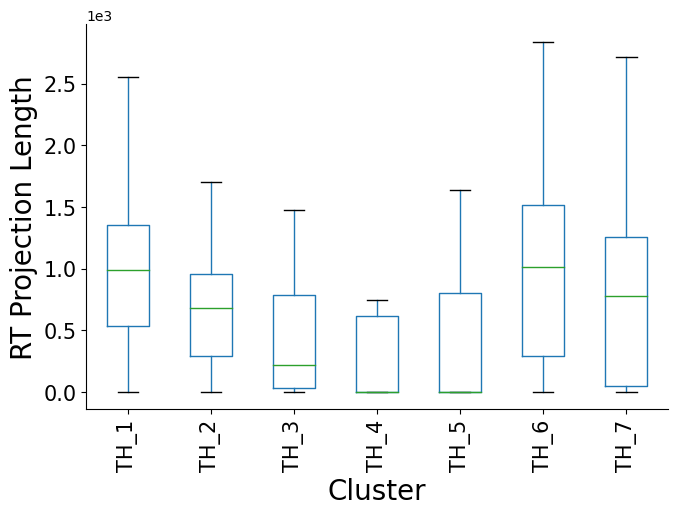

In [13]:
print(clusterRTlength)
import pandas as pd
dataframe={}
for i in range(1,8):
    
    s = pd.Series(clusterRTlength[i])
    dataframe['TH_'+str(i)]=s 
data = pd.DataFrame(dataframe)
plt.figure(figsize=(7.5, 5)) 
ax=plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
data.boxplot(fontsize=15,showfliers=False)
ax.grid(False)
plt.xticks(rotation = 90)
# plt.xlabel('Soma Region')
plt.ylabel('RT Projection Length',fontsize=20)
plt.xlabel('Cluster',fontsize=20)
plt.ticklabel_format(axis="y", style="sci", scilimits=(0,0))
# plt.savefig('../resource/svg/ConvexHullVolume.pdf',format='pdf',bbox_inches = 'tight')#保存为.svg格式
plt.show()

{1: [869, 998, 0, 379, 153, 103, 898, 531, 1079, 50, 1666, 1479, 667, 1272, 990, 1606, 1693, 1930, 6, 752, 1356, 1007, 1321, 2557, 698], 2: [105, 1039, 679, 0, 83, 342, 6, 130, 373, 526, 712, 1706, 959, 1442, 662, 692, 567, 1411, 293, 791, 1405, 482, 684, 730, 767, 1246, 7, 2892, 24], 3: [63, 0, 221, 358, 758, 86, 0, 811, 361, 1476, 930, 2318, 137, 0, 0], 4: [619, 0, 0, 0, 747, 0, 0, 218, 1570], 5: [0, 1186, 1493, 0, 1638, 3868, 45, 90, 2902, 0, 0, 0, 0, 0, 0, 204, 0, 0, 801, 0, 0, 1220, 0, 0, 0, 0, 1518, 313, 531, 42, 0, 838, 557], 6: [316, 1166, 916, 0, 1060, 212, 0, 0, 1265, 593, 814, 970, 1191, 1448, 1612, 1628, 1488, 0, 3838, 2839, 404, 5146, 1715, 20], 7: [1103, 61, 752, 921, 1258, 314, 6, 681, 58, 0, 496, 0, 893, 379, 1152, 1085, 1252, 799, 0, 0, 0, 1086, 1773, 2266, 1174, 1584, 2718, 2471, 1971, 337, 0, 658, 1959, 0, 1815, 1462, 588, 1037, 1189, 1611, 1643, 640, 1164, 579, 0, 0, 0, 0]}
0.96
0.9655172413793104
0.7333333333333333
0.4444444444444444
0.48484848484848486
0.833333333

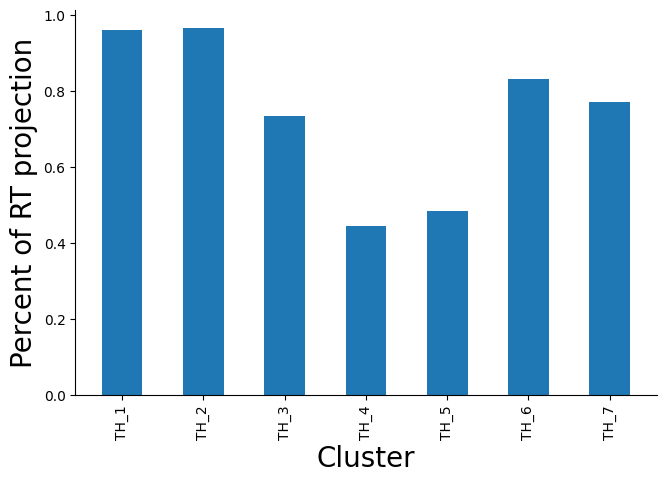

In [11]:
print(clusterRTlength)
import pandas as pd
dataframe=[]
indexs=[]
for i in range(1,8):
    
    s = pd.Series(clusterRTlength[i])
    ratio  = s[s>0].shape[0]/s.shape[0]
    print(ratio)
    indexs.append('TH_'+str(i))
    dataframe.append(ratio)
    # print(s)
data = (dataframe)
plt.figure(figsize=(7.5, 5)) 
ax=plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.bar(indexs,data,width=0.5)
ax.grid(False)
plt.xticks(rotation = 90)
# plt.xlabel('Soma Region')
plt.ylabel('Percent of RT projection',fontsize=20)
plt.xlabel('Cluster',fontsize=20)
plt.ticklabel_format(axis="y", style="sci", scilimits=(0,0))
# plt.savefig('../resource/svg/ConvexHullVolume.pdf',format='pdf',bbox_inches = 'tight')#保存为.svg格式
plt.show()

In [45]:




# matplotlib.use('module://matplotlib_inline.backend_inline')
# %matplotlib inline
rtDilationMask,rtDilationMaskheader = nrrd.read('../resource/rt/rtDilationMask.nrrd')
rtDilationMask200,rtDilationMask200header = nrrd.read('../resource/rt/rtDilationMask100.nrrd')
def getStreamLine():
    iondata = IONData.IONData()

    flatenPara=rtFlatmap.createSurfaceGraph()

    res,gridpath = iondata.getFileFromServer("rtboundaryLaplace-20.nrrd")
    grid,header = nrrd.read(gridpath)

    resdv0,dv0Path=iondata.getFileFromServer('rtdv0.nrrd')
    dv0,dv0header = nrrd.read(dv0Path)
    resdv1,dv1Path=iondata.getFileFromServer('rtdv1.nrrd')
    dv1,dv1header = nrrd.read(dv1Path)
    resdv2,dv2Path=iondata.getFileFromServer('rtdv2.nrrd')
    dv2,dv2header = nrrd.read(dv2Path)

    dv0=dv0.astype(np.float32)/1000-1
    dv1=dv1.astype(np.float32)/1000-1
    dv2=dv2.astype(np.float32)/1000-1
    
    return grid,dv0,dv1,dv2,flatenPara
def rtPathCube(neurontrees):
    edges=[]
    for neurontree in neurontrees:
        for p in neurontree.points:
            if p.z>5700:
                p.xyz[2]=11400-p.xyz[2]
        
        for edge in neurontree.edges:
            # print(index)

            points=[]
            for point in edge.data[0:-1:20]:
                points.append([point.xyz[0]/20,point.xyz[1]/20,point.xyz[2]/20])
            point=edge.data[-1]
            points.append([point.xyz[0]/20,point.xyz[1]/20,point.xyz[2]/20])
            out=[]
            for point in points:
                grid_position = BoundLaplace.FastTrilinearInterpolant(rtDilationMask, point) 
                if grid_position==10:
                    out.append(point)
            if len(out)>0:
                edges.append(out)
    pathcubes = np.zeros(rtDilationMask200.shape)
    pInRT =0
    for edge in edges:
        for p in edge:
            isInRT = rtDilationMask200[int(p[0]/5),int(p[1]/5),int(p[2]/5)]/10
            pInRT+=isInRT
            pathcubes[int(p[0]/5),int(p[1]/5),int(p[2]/5)] = isInRT
    return np.sum(pathcubes),len(edges),pInRT
    

def flatneuron(neurontree,grid,dv0,dv1,dv2,flatenPara,img=None,color=[0,0,255]):
    
    index=0
    newedgesh=[]
    newedgesv=[]
    minx =99999
    maxx =0
    for p in neurontree.points:
        if p.z>5700:
            p.xyz[2]=11400-p.xyz[2]
    for edge in neurontree.edges:
        # print(index)
        index+=1
        points=[]
        for point in edge.data[0:-1:20]:
            points.append([point.xyz[0]/20,point.xyz[1]/20,point.xyz[2]/20])
        point=edge.data[-1]
        points.append([point.xyz[0]/20,point.xyz[1]/20,point.xyz[2]/20])
        # out=BoundLaplace.ComputeStreamlines(grid,dv0,dv1,
        #                                 dv2,copy.deepcopy(points))
        out=[]
        for point in points:
            grid_position = BoundLaplace.FastTrilinearInterpolant(rtDilationMask, point) 
            if grid_position!=10:
                # print("not in the boundary range")
                # print(point)
                out.append([0,[0,0,0],[0,0,0]])
                continue
            length,outerpoint,innerpoint = BoundLaplace.CreateStreamline(grid, dv0, dv1, dv2,point[0],point[1],point[2], 0.1)
            out.append([length,outerpoint,innerpoint ])
        newedgeh = []
        newedgev = []
        
        ii = 0
        for p in out:
            depth = p[0]
            if depth != 0:
                if minx>points[ii][0]:
                    minx = points[ii][0]
                if maxx<points[ii][0]:
                    maxx = points[ii][0]
                newedgeh.append([points[ii][0],depth,points[ii][2]])
                newedgev.append(out[ii][1])
            ii += 1
        if len(newedgeh)>0:
            newedgesh.append(newedgeh)
            newedgesv.append(newedgev)

    if maxx-minx>0:
        plt.subplots(figsize=((maxx-minx)/20,7))
        ax = plt.subplot(111)  
        ax.spines['top'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.invert_yaxis()
        plt.xlim(minx,maxx)
        for edge in newedgesh:
            
            if len(edge):
                ax.plot(np.array(edge)[:,0],np.array(edge)[:,1],ls='-',linewidth=0.5,c='k',zorder=0) 
        plt.yticks([])
        plt.xticks([])
    if img is None:
        img = io.imread(r'../resource/rt/rtflatmap.png')
    fig,ax = plt.subplots(figsize=(16,17))
 
    for edge in newedgesv:
        prePoint = None
        for p in edge:
            p2d = rtFlatmap.map2Flatmap(flatenPara,np.array(p)*2,True)
            if prePoint is not None and len(p2d)==2:
                rr,cc = draw.line(int(prePoint[1]),int(prePoint[0]),int(p2d[1]),int(p2d[0]))
                img[rr,cc] = color
            if len(p2d)==2:
                prePoint =p2d
    io.imshow(img)
    # for edge in neurontree.edges:
    #     points=[]
    #     for point in edge.data:
    #         points.append([point.xyz[0]/20,point.xyz[1]/20,point.xyz[2]/20])
    #     ax.plot(np.array(points)[:,0],np.array(points)[:,1],ls='-',c='k',zorder=0)   
    # plt.show()

def flatneuronSum(neurontree,grid,dv0,dv1,dv2,flatenPara,img=None):
    
    index=0
    newedgesh=[]
    newedgesv=[]
    minx =99999
    maxx =0
    for p in neurontree.points:
        if p.z>5700:
            p.xyz[2]=11400-p.xyz[2]
    for edge in neurontree.edges:
        # print(index)
        index+=1
        points=[]
        for point in edge.data[0:-1:20]:
            points.append([point.xyz[0]/20,point.xyz[1]/20,point.xyz[2]/20])
        point=edge.data[-1]
        points.append([point.xyz[0]/20,point.xyz[1]/20,point.xyz[2]/20])
        # out=BoundLaplace.ComputeStreamlines(grid,dv0,dv1,
        #                                 dv2,copy.deepcopy(points))
        out=[]
        for point in points:
            grid_position = BoundLaplace.FastTrilinearInterpolant(rtDilationMask, point) 
            if grid_position!=10:
                # print("not in the boundary range")
                # print(point)
                out.append([0,[0,0,0],[0,0,0]])
                continue
            length,outerpoint,innerpoint = BoundLaplace.CreateStreamline(grid, dv0, dv1, dv2,point[0],point[1],point[2], 0.1)
            out.append([length,outerpoint,innerpoint ])
        newedgeh = []
        newedgev = []
        
        ii = 0
        for p in out:
            depth = p[0]
            if depth != 0:
                if minx>points[ii][0]:
                    minx = points[ii][0]
                if maxx<points[ii][0]:
                    maxx = points[ii][0]
                newedgeh.append([points[ii][0],depth,points[ii][2]])
                newedgev.append(out[ii][1])
            ii += 1
        if len(newedgeh)>0:
            newedgesh.append(newedgeh)
            newedgesv.append(newedgev)

    if maxx-minx>0:
        plt.subplots(figsize=((maxx-minx)/20,7))
        ax = plt.subplot(111)  
        ax.spines['top'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.invert_yaxis()
        plt.xlim(minx,maxx)
        for edge in newedgesh:
            
            if len(edge):
                ax.plot(np.array(edge)[:,0],np.array(edge)[:,1],ls='-',linewidth=0.5,c='k',zorder=0) 
        plt.yticks([])
        plt.xticks([])
    if img is None:
        img = io.imread(r'../resource/rt/rtflatmap.png')
    fig,ax = plt.subplots(figsize=(16,17))
 
    for edge in newedgesv:
        prePoint = None
        for p in edge:
            p2d = rtFlatmap.map2Flatmap(flatenPara,np.array(p)*2,True)
            if prePoint is not None and len(p2d)==2:
                rr,cc = draw.line(int(prePoint[1]),int(prePoint[0]),int(p2d[1]),int(p2d[0]))
                img[rr,cc] = img[rr,cc]+1
            if len(p2d)==2:
                prePoint =p2d
    io.imshow(img)
    # for edge in neurontree.edges:
    #     points=[]
    #     for point in edge.data:
    #         points.append([point.xyz[0]/20,point.xyz[1]/20,point.xyz[2]/20])
    #     ax.plot(np.array(points)[:,0],np.array(points)[:,1],ls='-',c='k',zorder=0)   
    # plt.show()


if __name__ == '__main__':
    import IONData 

    # grid,dv0,dv1,dv2,flatenPara = getStreamLine()

    # iondata =IONData.IONData()

    # fig,ax = plt.subplots(figsize=(11,7))
    
    # neurontree = iondata.getNeuronTreeByID('210662','070.swc')

    # rtPathCube([neurontree])
    # flatneuron(neurontree,grid,dv0,dv1,dv2,flatenPara)
    # plt.savefig('../resource/thsample/rtflatmap/test070.png', format='png', dpi=300)

# 不同脑区的神经元

In [66]:
import pandas as pd
import IONData 
iondata =IONData.IONData()
def loadClusterCSV(filename,cluster=None):
    neurons = pd.read_csv(filename)
    neuronsArray= neurons.to_numpy()
    neuronScene=[]
    for neuron in neuronsArray:
        # print(str(neuron[2])[0])
        neurondict={}
        neurondict['cluster'] = neuron[1]
        neurondict['sampleid'] = str(neuron[2])[0:6]
        neurondict['name']=str(neuron[2])[6:]+'.swc'
        if cluster ==neuron[1] or cluster ==None:
            neuronScene.append(neurondict)
    return neuronScene
import pickle

f = open('../resource/cluster_eachNeuron/TH20221208.pckl', 'rb')
obj = pickle.load(f)
f.close()

neuronScene=[]
for neuron in obj:
        # print(str(neuron[2])[0])
        neurondict={}
        neurondict['sampleid'] = str(neuron)[0:6]
        neurondict['name']=str(neuron)[6:]

        neuronScene.append(neurondict)

source_regions_sort_index = ['VPM','VPL','VPMpc','VPLpc','LGd','MG','VAL','AM','SMT','MD','LP','PO','LD','VM','RE','CM','TH','ar','CL','Eth','PIL','PoT','SPFp','ZI']
regionNeurons={'Other':[]}

for regions in source_regions_sort_index:
    regionNeurons[regions]=[]
for neuron in neuronScene:
    property = iondata.getNeuronPropertyByID(neuron['sampleid'], neuron['name'])
    if property['somaregion'] not in source_regions_sort_index:
        regionNeurons['Other'].append(neuron)
        continue
    else:
        regionNeurons[property['somaregion']].append(neuron)


In [84]:
len(neuronScene)
Scene.createScene(neuronScene,'../resource/rt.nv')

In [78]:
import BrainRegion as BR 
import numpy as np
br = BR.BrainRegion()
br.praseJson()
rtLength={}
for neuron in neuronScene:
    property = iondata.getNeuronPropertyByID(neuron['sampleid'], neuron['name'])
    
    brproperty=BR.RegionProperty(copy.deepcopy(br))
    brproperty.setProperty(property['projectregion'])
    regionsum = brproperty.getSumProperty('RT')
    rtLength[neuron['sampleid']+neuron['name']] = regionsum


In [82]:
sum=0
for neuron in rtLength:
    sum+=rtLength[neuron]>430
print(sum,len(rtLength),sum/len(rtLength))

131 239 0.5481171548117155


# 每个神经元在RT脑区内的投射范围

In [68]:
for region in regionNeurons:
    for neuron in regionNeurons[region]:
        neuronT = iondata.getNeuronTreeByID(neuron['sampleid'], neuron['name'])
        cubecount,branchcount,pcount = rtPathCube([neuronT])
        neuron['cubecount']=cubecount
        neuron['branchcount']=branchcount
        neuron['pointcount']=pcount


exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210098/003.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210098/004.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210098/014.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210098/015.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210098/017.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210661/051.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210661/055.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210661/192.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210662/107.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210727/023.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210727/057.swc
exist  d:\project\python\neuron-

In [69]:
sum=0
for region in regionNeurons:
    neurons = regionNeurons[region]
    print(len(neurons))
    for neuron in neurons:
        # print(neuron['pointcount'])
        if neuron['pointcount']>0:
            sum+=1
print(sum)

26
10
26
3
4
0
0
5
0
0
43
3
42
0
0
0
8
6
14
13
8
3
15
3
7
230


# 各脑区神经元个数最多的样本

In [70]:
from collections import Counter
regionMaxSample={}
for region in regionNeurons:
    
    samplearray=[]
    for neuron in regionNeurons[region]:
        samplearray.append(neuron['sampleid'])
    number = Counter(samplearray)
    result = number.most_common()
    if len(result)>=1:
        regionMaxSample[region]=result[0][0]
        print(region,result[0][0],result[0][1])

Other 211984 10
VPM 210726 4
VPL 210726 22
VPMpc 211984 3
VPLpc 210726 4
VAL 211181 3
MD 211984 23
LP 210662 2
PO 210661 32
CM 210098 4
TH 210727 2
ar 210727 9
CL 210662 7
Eth 210661 6
PIL 210726 3
PoT 210661 8
SPFp 210727 2
ZI 210727 6


# 各脑区神经元在rt投射范围和

In [71]:
sum=0
for region in regionNeurons:
    sum+=len(regionNeurons[region])
    print(region,len(regionNeurons[region]))
print(sum)

Other 26
VPM 10
VPL 26
VPMpc 3
VPLpc 4
LGd 0
MG 0
VAL 5
AM 0
SMT 0
MD 43
LP 3
PO 42
LD 0
VM 0
RE 0
CM 8
TH 6
ar 14
CL 13
Eth 8
PIL 3
PoT 15
SPFp 3
ZI 7
239


In [72]:
from re import S
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
%matplotlib inline
dataframe={}
for region in regionNeurons:
    cubecounts=[]
    for neuron in regionNeurons[region]:
        # if region in regionMaxSample and neuron['sampleid']==regionMaxSample[region]:
            cubecounts.append(neuron['pointcount'])

    s = pd.Series(np.array(cubecounts))
    if s.size>0:
        dataframe[region]=s 
regionSampleCubeCount = pd.DataFrame(dataframe)
regionSampleCubeCount.sum()

Other    1356.0
VPM       610.0
VPL      1648.0
VPMpc     114.0
VPLpc     319.0
VAL       158.0
MD       1091.0
LP        346.0
PO       4330.0
CM        118.0
TH        354.0
ar       1418.0
CL       1205.0
Eth      1120.0
PIL         1.0
PoT      1593.0
SPFp       93.0
ZI        593.0
dtype: float64

In [73]:
regionSampleCubeCount

,Other,VPM,VPL,VPMpc,VPLpc,VAL,MD,LP,PO,CM,TH,ar,CL,Eth,PIL,PoT,SPFp,ZI
0,69.0,47.0,36.0,4.0,70.0,54.0,42.0,143.0,163.0,62.0,7.0,64.0,120.0,139.0,0.0,360.0,93.0,151.0
1,10.0,145.0,178.0,6.0,17.0,14.0,7.0,141.0,80.0,12.0,106.0,160.0,155.0,307.0,1.0,43.0,0.0,164.0
2,47.0,134.0,142.0,104.0,9.0,57.0,6.0,62.0,87.0,9.0,126.0,47.0,74.0,230.0,0.0,121.0,0.0,192.0
3,11.0,129.0,16.0,NaN,223.0,29.0,3.0,NaN,110.0,9.0,77.0,202.0,112.0,174.0,NaN,102.0,NaN,4.0
4,10.0,25.0,71.0,NaN,NaN,4.0,10.0,NaN,239.0,9.0,21.0,81.0,130.0,58.0,NaN,250.0,NaN,4.0
5,66.0,19.0,52.0,NaN,NaN,NaN,11.0,NaN,140.0,2.0,17.0,165.0,206.0,13.0,NaN,61.0,NaN,42.0
6,122.0,14.0,67.0,NaN,NaN,NaN,9.0,NaN,206.0,9.0,NaN,90.0,130.0,153.0,NaN,40.0,NaN,36.0
7,150.0,0.0,16.0,NaN,NaN,NaN,10.0,NaN,114.0,6.0,NaN,127.0,67.0,46.0,NaN,307.0,NaN,NaN
8,181.0,81.0,27.0,NaN,NaN,NaN,55.0,NaN,147.0,NaN,NaN,103.0,87.0,NaN,NaN,136.0,NaN,NaN
9,0.0,16.0,34.0,NaN,NaN,NaN,14.0,NaN,200.0,NaN,NaN,92.0,93.0,NaN,NaN,62.0,NaN,NaN


In [74]:
rtCubeCount = regionSampleCubeCount>10
rtCubeCount.sum().sum()
# regionSampleCubeCountc

170

In [75]:
rtCubeCount.sum().sum()/len(neuronScene)

0.7112970711297071

# 各脑区神经元个数最多的样本神经元在RT内的投射范围

In [9]:
regionSampleAllCubeCount={}
for region in source_regions_sort_index:
    neurons=[]
    for neuron in regionNeurons[region]:
        if region in regionMaxSample and neuron['sampleid']==regionMaxSample[region]:
            neuronT = iondata.getNeuronTreeByID(neuron['sampleid'], neuron['name'])
            neurons.append(neuronT)
    cubecount,branchcount = rtPathCube(neurons)
    if region in regionMaxSample:
        regionSampleAllCubeCount[region]=cubecount

# 各脑区单个样本神经元overlay

{'VPM': 0.95, 'VPL': 0.42424242424242425, 'VPLpc': 0.7446808510638298, 'VAL': 1.0, 'MD': 0.7894736842105263, 'LP': 0.925, 'PO': 0.48091603053435117, 'CM': 1.0, 'TH': 1.0, 'ar': 0.4728682170542636, 'CL': 0.6460674157303371, 'Eth': 0.9055555555555556, 'PIL': 1.0, 'PoT': 0.7441860465116279, 'SPFp': 0.9666666666666667, 'ZI': 0.9047619047619048}


<AxesSubplot:>

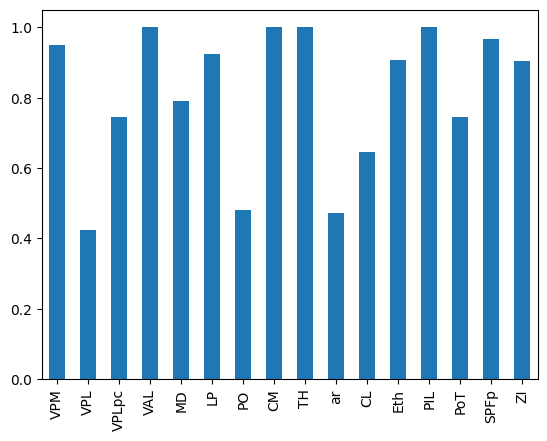

In [10]:
regionSampleAllCubeCount
sampleoverlay={}
regioncubesum = regionSampleCubeCount.sum()
for i in range(len(regioncubesum)):
    sampleoverlay[regioncubesum.index[i]]=regionSampleAllCubeCount[regioncubesum.index[i]]/regioncubesum[regioncubesum.index[i]]
print(sampleoverlay)
overlayseries = pd.Series(sampleoverlay)
overlayseries.plot.bar()

# 不同脑区神经元在RT的投射范围分布

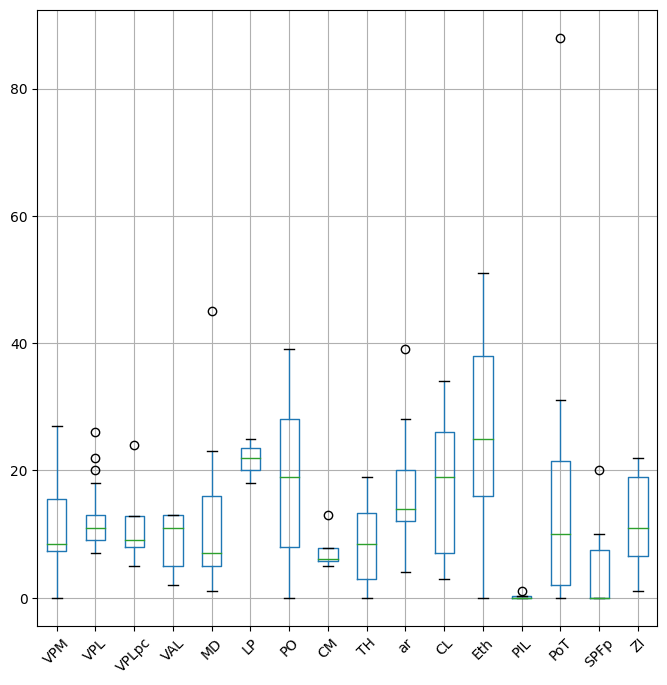

In [13]:
from re import S
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
%matplotlib inline
dataframe={}
for region in source_regions_sort_index:
    cubecounts=[]
    for neuron in regionNeurons[region]:
        cubecounts.append(neuron['cubecount'])

    s = pd.Series(np.array(cubecounts))
    if s.size>0:
        dataframe[region]=s 
data = pd.DataFrame(dataframe)
plt.figure(figsize=(8, 8)) 
data.boxplot()
plt.xticks(rotation=45)
plt.show()

In [51]:
regionCubeCount={}
for region in source_regions_sort_index:
    neurons=[]
    for neuron in regionNeurons[region]:
        neuronT = iondata.getNeuronTreeByID(neuron['sampleid'], neuron['name'])
        neurons.append(neuronT)
    cubecount,branchcount,pcount = rtPathCube(neurons)
    regionCubeCount[region]=cubecount

exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210661/146.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210661/206.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210661/208.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210726/062.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210726/080.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210726/131.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210726/132.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210727/022.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/211181/072.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/211986/068.swc


ValueError: too many values to unpack (expected 2)

In [84]:
data.sum()

VPM      114.0
VPL      329.0
VPLpc     47.0
VAL       44.0
MD       231.0
LP        65.0
PO       778.0
CM        30.0
TH        67.0
ar       229.0
CL       235.0
Eth      221.0
PIL        1.0
PoT      288.0
SPFp      30.0
ZI        85.0
dtype: float64

In [86]:
regionCubeCount

{'VPM': 98.0,
 'VPL': 151.0,
 'VPMpc': 0.0,
 'VPLpc': 35.0,
 'LGd': 0.0,
 'MG': 0.0,
 'VAL': 43.0,
 'AM': 0.0,
 'SMT': 0.0,
 'MD': 167.0,
 'LP': 57.0,
 'PO': 357.0,
 'LD': 0.0,
 'VM': 0.0,
 'RE': 0.0,
 'CM': 30.0,
 'TH': 57.0,
 'ar': 101.0,
 'CL': 136.0,
 'Eth': 199.0,
 'PIL': 1.0,
 'PoT': 188.0,
 'SPFp': 29.0,
 'ZI': 70.0}

# 各脑区所有神经元overlay

{'VPM': 0.8596491228070176, 'VPL': 0.45896656534954405, 'VPLpc': 0.7446808510638298, 'VAL': 0.9772727272727273, 'MD': 0.7229437229437229, 'LP': 0.8769230769230769, 'PO': 0.4588688946015424, 'CM': 1.0, 'TH': 0.8507462686567164, 'ar': 0.4410480349344978, 'CL': 0.5787234042553191, 'Eth': 0.9004524886877828, 'PIL': 1.0, 'PoT': 0.6527777777777778, 'SPFp': 0.9666666666666667, 'ZI': 0.8235294117647058}


<AxesSubplot:>

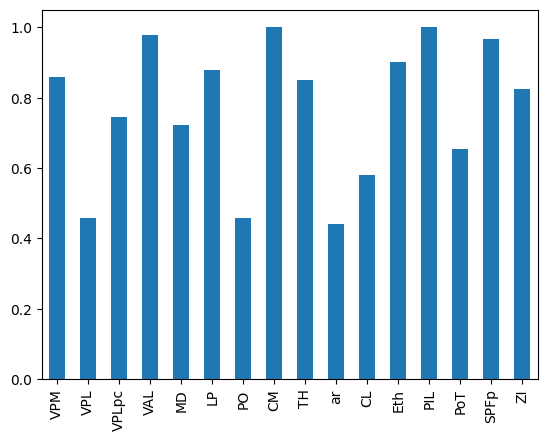

In [95]:
overlay={}
regioncubesum = data.sum()
for i in range(len(regioncubesum)):
    overlay[regioncubesum.index[i]]=regionCubeCount[regioncubesum.index[i]]/regioncubesum[regioncubesum.index[i]]
print(overlay)
overlayseries = pd.Series(overlay)
overlayseries.plot.bar()

# 各脑区所有神经元数量

In [50]:

datatrue = data>0
t= datatrue.sum()
neuroncount={}
for i in range(len(t)):
    # print(t.index[i])
    neuroncount[t.index[i]]=len(regionNeurons[t.index[i]])
print(neuroncount)
s = pd.Series(neuroncount)
df=pd.DataFrame([t,s-t])
df = df.T

df.plot.bar(stacked=True,figsize=(8,1))


NameError: name 'data' is not defined

In [67]:
df.T

,0,1
VPM,9,1
VPL,27,0
VPLpc,4,0
VAL,5,0
MD,20,0
LP,3,0
PO,39,2
CM,4,0
TH,6,2
ar,14,0


# 所有神经元在rt的flatmap

## 不同脑区神经元一个图

In [6]:
import random
for region in source_regions_sort_index:
    img = io.imread(r'../resource/rt/rtflatmapbgd.png')
    img[:]=0
    for neuron in regionNeurons[region]:
        # if not os.path.isfile("../resource/thsample/rtflatmap/"+region+neuron['sampleid']+ neuron['name']+'flat.png'):
        neuronT = iondata.getNeuronTreeByID(neuron['sampleid'], neuron['name'])
        color=[random.randrange(0, 256),random.randrange(0, 256),random.randrange(0, 256)]
        flatneuronSum(neuronT,grid,dv0,dv1,dv2,flatenPara,img)
    if len(regionNeurons[region])>0:
        # plt.savefig("../resource/thsample/rtflatmap/"+region+'flatbgd.png', format='png', dpi=100)
        io.imsave("../resource/thsample/rtflatmap/"+region+'flatbgd.png',img)
    

d:\Program Files\anaconda3\envs\neuronVis\lib\site-packages\skimage\io\_plugins\matplotlib_plugin.py:150: UserWarning: Low image data range; displaying image with stretched contrast.
  lo, hi, cmap = _get_display_range(image)


not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary


D:\project\python\AppData\Local\Temp\ipykernel_30560\4012749782.py:12: UserWarning: ../resource/thsample/rtflatmap/VPMflatbgd.png is a low contrast image
  io.imsave("../resource/thsample/rtflatmap/"+region+'flatbgd.png',img)


not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up bo

D:\project\python\AppData\Local\Temp\ipykernel_30560\4012749782.py:12: UserWarning: ../resource/thsample/rtflatmap/VPLflatbgd.png is a low contrast image
  io.imsave("../resource/thsample/rtflatmap/"+region+'flatbgd.png',img)
D:\project\python\AppData\Local\Temp\ipykernel_30560\4012749782.py:12: UserWarning: ../resource/thsample/rtflatmap/VPLpcflatbgd.png is a low contrast image
  io.imsave("../resource/thsample/rtflatmap/"+region+'flatbgd.png',img)
D:\project\python\AppData\Local\Temp\ipykernel_30560\4012749782.py:12: UserWarning: ../resource/thsample/rtflatmap/VALflatbgd.png is a low contrast image
  io.imsave("../resource/thsample/rtflatmap/"+region+'flatbgd.png',img)
D:\project\python\AppData\Local\Temp\ipykernel_30560\4012749782.py:12: UserWarning: ../resource/thsample/rtflatmap/MDflatbgd.png is a low contrast image
  io.imsave("../resource/thsample/rtflatmap/"+region+'flatbgd.png',img)
D:\project\python\AppData\Local\Temp\ipykernel_30560\4012749782.py:12: UserWarning: ../resource

...

D:\project\python\AppData\Local\Temp\ipykernel_30560\4012749782.py:12: UserWarning: ../resource/thsample/rtflatmap/Ethflatbgd.png is a low contrast image
  io.imsave("../resource/thsample/rtflatmap/"+region+'flatbgd.png',img)
D:\project\python\AppData\Local\Temp\ipykernel_30560\4012749782.py:12: UserWarning: ../resource/thsample/rtflatmap/PILflatbgd.png is a low contrast image
  io.imsave("../resource/thsample/rtflatmap/"+region+'flatbgd.png',img)


not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary


D:\project\python\AppData\Local\Temp\ipykernel_30560\4012749782.py:12: UserWarning: ../resource/thsample/rtflatmap/PoTflatbgd.png is a low contrast image
  io.imsave("../resource/thsample/rtflatmap/"+region+'flatbgd.png',img)
D:\project\python\AppData\Local\Temp\ipykernel_30560\4012749782.py:12: UserWarning: ../resource/thsample/rtflatmap/SPFpflatbgd.png is a low contrast image
  io.imsave("../resource/thsample/rtflatmap/"+region+'flatbgd.png',img)


not in up boundary
not in up boundary
not in up boundary


D:\project\python\AppData\Local\Temp\ipykernel_30560\4012749782.py:12: UserWarning: ../resource/thsample/rtflatmap/ZIflatbgd.png is a low contrast image
  io.imsave("../resource/thsample/rtflatmap/"+region+'flatbgd.png',img)


In [23]:
lut = pd.read_csv('../resource/LUT.csv')
lut = lut.to_numpy()
lut=lut[:,1:4]
print(lut[0])

[255 255 255]


In [62]:
import random
from skimage import filters
# fig,ax = plt.subplots(figsize=(15,15))
imgbgd = io.imread('../resource/rt/rtflatmap.png')
maxvalue=0
for region in source_regions_sort_index:
    if os.path.isfile('../resource/thsample/rtflatmap/'+region+'flatbgd.png'):
        img = io.imread('../resource/thsample/rtflatmap/'+region+'flatbgd.png')
        print(region,np.max(img))
        if np.max(img)==0:
            continue
        if maxvalue<np.max(img):
            maxvalue=np.max(img)
for region in source_regions_sort_index:
    if os.path.isfile('../resource/thsample/rtflatmap/'+region+'flatbgd.png'):
        img = io.imread('../resource/thsample/rtflatmap/'+region+'flatbgd.png')

        img = img*255/maxvalue
        img1 = filters.gaussian(img,sigma=4)
        img1 = img1[:,:,0]
        img2 = img1.reshape([img1.shape[0]*img1.shape[1]])
        # print(region)
        img2 = img2*20
        img2=img2.astype(np.int8)
        img3 = lut[img2]
        img4 = img3.reshape([img1.shape[0],img1.shape[1],3])
        img4[imgbgd[:,:,0]==0]=[0,0,0]
        io.imsave("../resource/thsample/rtflatmap/"+region+'flatblur.png',img4)
        # io.imshow(img)
        # plt.show()
        # break

d:\Program Files\anaconda3\envs\neuronVis\lib\site-packages\skimage\_shared\utils.py:348: RuntimeWarning: Images with dimensions (M, N, 3) are interpreted as 2D+RGB by default. Use `multichannel=False` to interpret as 3D image with last dimension of length 3.
  return func(*args, **kwargs)
D:\project\python\AppData\Local\Temp\ipykernel_4844\1458036507.py:28: UserWarning: ../resource/thsample/rtflatmap/VPMflatblur.png is a low contrast image
  io.imsave("../resource/thsample/rtflatmap/"+region+'flatblur.png',img4)
Lossy conversion from int64 to uint8. Range [0, 255]. Convert image to uint8 prior to saving to suppress this warning.


VPM 9
VPL 13
VPLpc 5
VAL 5
MD 9
LP 6
PO 19
CM 4
TH 7
ar 11
CL 17
Eth 8
PIL 0
PoT 15
SPFp 8
ZI 8


D:\project\python\AppData\Local\Temp\ipykernel_4844\1458036507.py:28: UserWarning: ../resource/thsample/rtflatmap/VPLflatblur.png is a low contrast image
  io.imsave("../resource/thsample/rtflatmap/"+region+'flatblur.png',img4)
Lossy conversion from int64 to uint8. Range [0, 255]. Convert image to uint8 prior to saving to suppress this warning.
D:\project\python\AppData\Local\Temp\ipykernel_4844\1458036507.py:28: UserWarning: ../resource/thsample/rtflatmap/VPLpcflatblur.png is a low contrast image
  io.imsave("../resource/thsample/rtflatmap/"+region+'flatblur.png',img4)
Lossy conversion from int64 to uint8. Range [0, 255]. Convert image to uint8 prior to saving to suppress this warning.
D:\project\python\AppData\Local\Temp\ipykernel_4844\1458036507.py:28: UserWarning: ../resource/thsample/rtflatmap/VALflatblur.png is a low contrast image
  io.imsave("../resource/thsample/rtflatmap/"+region+'flatblur.png',img4)
Lossy conversion from int64 to uint8. Range [0, 255]. Convert image to uint8

## 所有神经元一个图

In [4]:
import random
img = io.imread(r'../resource/rt/rtflatmap.png')
for region in source_regions_sort_index:
    color=[random.randrange(0, 256),random.randrange(0, 256),random.randrange(0, 256)]
    for neuron in regionNeurons[region]:
        # if not os.path.isfile("../resource/thsample/rtflatmap/"+region+neuron['sampleid']+ neuron['name']+'flat.png'):
        # print('test')
        neuronT = iondata.getNeuronTreeByID(neuron['sampleid'], neuron['name'])
        flatneuron(neuronT,grid,dv0,dv1,dv2,flatenPara,img,color)

plt.savefig("../resource/thsample/rtflatmap/"+'rtflat.png', format='png', dpi=300)

test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test
test


## 一个神经元一个图

In [3]:
for region in source_regions_sort_index:
    for neuron in regionNeurons[region]:
        if not os.path.isfile("../resource/thsample/rtflatmap/"+region+neuron['sampleid']+ neuron['name']+'flat.png'):
            neuronT = iondata.getNeuronTreeByID(neuron['sampleid'], neuron['name'])
            flatneuron(neuronT,grid,dv0,dv1,dv2,flatenPara)
            plt.savefig("../resource/thsample/rtflatmap/"+region+neuron['sampleid']+ neuron['name']+'flat.png', format='png', dpi=300)


d:\Program Files\anaconda3\envs\neuronVis\lib\site-packages\skimage\io\_plugins\matplotlib_plugin.py:150: UserWarning: Low image data range; displaying image with stretched contrast.
  lo, hi, cmap = _get_display_range(image)


not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary


D:\project\python\AppData\Local\Temp\ipykernel_24536\685348280.py:112: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig,ax = plt.subplots(figsize=(16,17))


not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up boundary
not in up bo

# iso pathcube

In [145]:
import sys,copy,os,inspect
if hasattr(sys.modules[__name__], '__file__'):
    _file_name = __file__
else:
    _file_name = inspect.getfile(inspect.currentframe())
CURRENT_FILE_PATH = os.path.dirname(_file_name)
sys.path.append(os.getcwd()+"/../neuronVis")


import matplotlib.pyplot as plt
from skimage import draw, io
import matplotlib
import BoundLaplace
import copy
import rtFlatmap
import BoundLaplace
import nrrd
import numpy as np
import IONData
# matplotlib.use('module://matplotlib_inline.backend_inline')
# %matplotlib inline
boundlaplace20,boundlaplace20header = nrrd.read('../resource/boundlaplace20.nrrd')
isoMask100,isoMask100header = nrrd.read('../resource/rt/mask_combinedISO_CLA-100.nrrd')

def isoPathCube(neurontrees):
    edges=[]
    for neurontree in neurontrees:
        for p in neurontree.points:
            if p.z>5700:
                p.xyz[2]=11400-p.xyz[2]
        
        for edge in neurontree.edges:
            # print(index)

            points=[]
            for point in edge.data[0:-1:20]:
                points.append([point.xyz[0]/20,point.xyz[1]/20,point.xyz[2]/20])
            point=edge.data[-1]
            points.append([point.xyz[0]/20,point.xyz[1]/20,point.xyz[2]/20])
            out=[]
            for point in points:
                grid_position = BoundLaplace.FastTrilinearInterpolant(boundlaplace20, point) 
                if grid_position==5:
                    out.append(point)
            if len(out)>0:
                edges.append(out)
    pathcubes = np.zeros(isoMask100.shape)
    for edge in edges:
        for p in edge:
            pathcubes[int(p[0]/5),int(p[1]/5),int(p[2]/5)] = isoMask100[int(p[0]/5),int(p[1]/5),int(p[2]/5)]
    return np.sum(pathcubes),len(edges)
    



In [146]:
for region in source_regions_sort_index:
    for neuron in regionNeurons[region]:
        neuronT = iondata.getNeuronTreeByID(neuron['sampleid'], neuron['name'])
        cubecount,branchcount = isoPathCube([neuronT])
        neuron['isocubecount']=cubecount
        neuron['isobranchcount']=branchcount

# rt投射范围 和 iso投射范围关系

VPM 9.0 380.0
VPM 16.0 773.0
VPM 27.0 779.0
VPM 19.0 420.0
VPM 8.0 278.0
VPM 6.0 228.0
VPM 7.0 218.0
VPM 0.0 0.0
VPM 14.0 799.0
VPM 8.0 65.0
VPL 11.0 269.0
VPL 26.0 424.0
VPL 20.0 283.0
VPL 8.0 244.0
VPL 12.0 265.0
VPL 14.0 233.0
VPL 11.0 101.0
VPL 7.0 144.0
VPL 9.0 81.0
VPL 10.0 255.0
VPL 9.0 194.0
VPL 12.0 175.0
VPL 7.0 47.0
VPL 7.0 99.0
VPL 7.0 269.0
VPL 22.0 399.0
VPL 10.0 89.0
VPL 12.0 329.0
VPL 12.0 139.0
VPL 17.0 292.0
VPL 9.0 283.0
VPL 11.0 227.0
VPL 12.0 245.0
VPL 14.0 253.0
VPL 18.0 607.0
VPL 10.0 0.0
VPL 12.0 209.0
VPLpc 9.0 111.0
VPLpc 9.0 306.0
VPLpc 5.0 223.0
VPLpc 24.0 466.0
VAL 13.0 549.0
VAL 5.0 183.0
VAL 13.0 929.0
VAL 11.0 431.0
VAL 2.0 455.0
MD 15.0 255.0
MD 3.0 4.0
MD 5.0 249.0
MD 1.0 651.0
MD 6.0 0.0
MD 5.0 1.0
MD 5.0 74.0
MD 7.0 326.0
MD 20.0 191.0
MD 5.0 74.0
MD 7.0 165.0
MD 11.0 510.0
MD 5.0 137.0
MD 45.0 570.0
MD 8.0 694.0
MD 19.0 940.0
MD 13.0 266.0
MD 22.0 110.0
MD 23.0 561.0
MD 6.0 223.0
LP 25.0 451.0
LP 22.0 321.0
LP 18.0 313.0
PO 25.0 550.0
PO 15.0 532.0


VPM       3940.0
VPL       6155.0
VPLpc     1106.0
VAL       2547.0
MD        6001.0
LP        1085.0
PO       14241.0
CM         529.0
TH        1852.0
ar        3826.0
CL        5482.0
Eth       4341.0
PIL        416.0
PoT       5251.0
SPFp       598.0
ZI        2303.0
dtype: float64

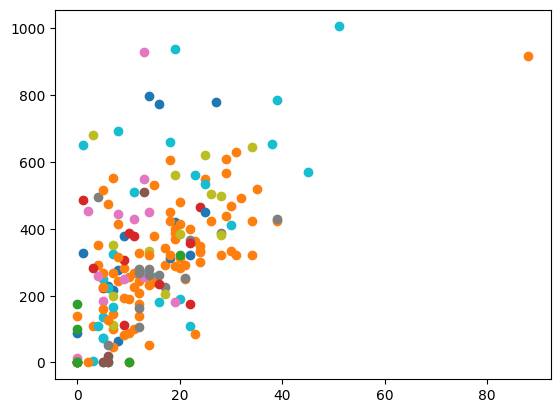

In [148]:
from re import S
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
%matplotlib inline
dataframe={}

for region in source_regions_sort_index:
    x=[]
    y=[]
    cubecounts=[]
    for neuron in regionNeurons[region]:
        # if region in regionMaxSample and neuron['sampleid']==regionMaxSample[region]:
        cubecounts.append(neuron['isocubecount'])
        print(region,neuron['cubecount'],neuron['isocubecount'])
        x.append(neuron['cubecount'])
        y.append(neuron['isocubecount'])
    s = pd.Series(np.array(cubecounts))
    plt.scatter(x,y)
    if s.size>0:
        dataframe[region]=s 
regionSampleISOCubeCount = pd.DataFrame(dataframe)
regionSampleISOCubeCount.sum()


In [137]:
regionSampleISOCubeCount

,VPM,VPL,VPLpc,VAL,MD,LP,PO,CM,TH,ar,CL,Eth,PIL,PoT,SPFp,ZI
0,0.0,1.0,0.0,0.0,10.0,1.0,2.0,1.0,0.0,1.0,7.0,0.0,0.0,2.0,4.0,4.0
1,1.0,2.0,1.0,0.0,0.0,8.0,3.0,3.0,3.0,0.0,19.0,0.0,0.0,5.0,0.0,1.0
2,0.0,2.0,0.0,0.0,0.0,0.0,2.0,0.0,4.0,1.0,6.0,0.0,1.0,1.0,0.0,0.0
3,1.0,1.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,11.0,9.0,0.0,6.0,2.0,0.0,0.0
4,3.0,1.0,NaN,0.0,0.0,NaN,0.0,NaN,1.0,1.0,18.0,4.0,NaN,0.0,0.0,2.0
5,1.0,3.0,NaN,NaN,0.0,NaN,1.0,NaN,4.0,0.0,1.0,1.0,NaN,2.0,0.0,0.0
6,0.0,3.0,NaN,NaN,1.0,NaN,2.0,NaN,0.0,1.0,4.0,2.0,NaN,6.0,NaN,0.0
7,0.0,1.0,NaN,NaN,4.0,NaN,0.0,NaN,1.0,0.0,2.0,1.0,NaN,0.0,NaN,NaN
8,0.0,0.0,NaN,NaN,10.0,NaN,1.0,NaN,NaN,4.0,13.0,2.0,NaN,5.0,NaN,NaN
9,1.0,0.0,NaN,NaN,3.0,NaN,1.0,NaN,NaN,1.0,24.0,NaN,NaN,1.0,NaN,NaN
